# Taller 1 — Notebook 03: Análisis, hipótesis y visualización

**MINE-4101: Ciencia de Datos Aplicada · Supervisión de contratación pública de bienes**

---

## Objetivo del notebook

Cubre los **Entregables 2 (Estrategia, 15%)** y **3 (Desarrollo, 40%)**. Sobre el dataset limpio
(`data/processed/secop_bienes_limpio.parquet`, generado en `02`) se formulan y contrastan **hipótesis
explícitas** sobre qué características de un contrato se asocian con las tres desviaciones de la ejecución,
usando estadística inferencial y visualización multivariada. Se reportan resultados **significativos y no
significativos**.

> **Ejecutar después de** `01_entendimiento` y `02_limpieza`.


## 2. Estrategia de análisis (Entregable 2 — 15%)

**Objetivo analítico.** Queremos identificar, desde el momento de la firma, qué contratos tienen mayor
probabilidad de **desviarse** en su ejecución, para focalizar la supervisión. Operacionalizamos "desviación"
en tres banderas construidas en `02` y analizadas **por separado** porque responden a mecanismos distintos:
`adicion_plazo` (el contrato requirió adiciones de plazo), `subejecucion` (no ejecutó el presupuesto
comprometido) y `sin_liquidar` (se cerró sin liquidar).

**Estrategia y técnicas.** (1) *Descriptivo*: prevalencia de cada desviación y su solapamiento. (2) *Bivariado
inferencial*: para cada bandera contrastamos hipótesis explícitas contra los atributos disponibles al firmar
—valor del contrato, modalidad, destino del gasto, sector, orden, tipo de contrato y tamaño del proveedor—.
Para pares **categórica vs bandera** usamos la prueba **χ² de independencia** acompañada de la **V de Cramér**
como tamaño de efecto; para **valor (numérico) vs bandera** usamos la prueba **U de Mann-Whitney** (no
paramétrica, robusta al fuerte sesgo del valor). (3) *Multivariado*: mapas de calor de la tasa de desviación
por combinaciones de atributos (p. ej. modalidad × destino, sector × orden) para detectar segmentos de alto
riesgo. **Justificación:** dado que la muestra es muy grande (n de decenas de miles), casi cualquier
asociación resulta estadísticamente significativa; por eso priorizamos el **tamaño de efecto** (V de Cramér,
diferencia de medianas) y no solo el p-valor para decidir qué criterios son útiles para la focalización. El
análisis se restringe al **periodo con ciclo comparable** definido en `01`–`02` (firma ≤ 2023), y para las
desviaciones que requieren cierre (`subejecucion`, `sin_liquidar`) solo a contratos con ciclo cerrado.


## 3. Desarrollo de la estrategia (Entregable 3 — 40%)

### 3.0 Preparación: carga, bases analíticas y utilidades


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'

RUTA_LIMPIO = '../data/processed/secop_bienes_limpio.parquet'
RUTA_FIGS = '../figs'
ALPHA = 0.05

d = pd.read_parquet(RUTA_LIMPIO)
print(f'Dataset limpio: {d.shape[0]:,} x {d.shape[1]}')

# Bases analíticas (comparabilidad de cohortes: firma <= 2023)
base_adic = d[d['periodo_analisis']].copy()                 # adición observable durante la ejecución
base_sub = d[d['subejecucion'].notna()].copy()              # ciclo cerrado & periodo & ejecución reportada
base_liq = d[d['sin_liquidar'].notna()].copy()              # ciclo cerrado & periodo
print(f'Base adición   (firma<=2023):            {len(base_adic):,}  | tasa {base_adic["adicion_plazo"].mean()*100:.1f}%')
print(f'Base subejecución (cerrado & reportado): {len(base_sub):,}  | tasa {base_sub["subejecucion"].mean()*100:.1f}%')
print(f'Base sin liquidar (cerrado):             {len(base_liq):,}  | tasa {base_liq["sin_liquidar"].mean()*100:.1f}%')


Dataset limpio: 196,391 x 52


Base adición   (firma<=2023):            121,644  | tasa 7.0%
Base subejecución (cerrado & reportado): 38,128  | tasa 7.9%
Base sin liquidar (cerrado):             68,351  | tasa 59.2%


In [2]:
# --- Utilidades de prueba de hipótesis ---
def cramers_v(ct):
    chi2 = stats.chi2_contingency(ct)[0]
    n = ct.values.sum(); k = min(ct.shape) - 1
    return np.sqrt(chi2 / (n * k)) if k > 0 else np.nan

def interp_v(v):
    return 'nulo' if v < 0.05 else 'pequeño' if v < 0.15 else 'moderado' if v < 0.25 else 'fuerte'

def test_categorica(df, flag, cat, min_n=200):
    '''χ² de independencia entre `cat` y `flag` + V de Cramér y tabla de tasas.'''
    sub = df[df[flag].notna()].copy()
    sub[flag] = sub[flag].astype(bool)
    ct = pd.crosstab(sub[cat], sub[flag])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    v = cramers_v(ct)
    tasas = sub.groupby(cat)[flag].agg(tasa='mean', n='size')
    tasas = tasas[tasas['n'] >= min_n].sort_values('tasa', ascending=False)
    tasas['tasa'] = (tasas['tasa'] * 100).round(1)
    return {'p': p, 'V': v, 'sig': p < ALPHA, 'efecto': interp_v(v), 'tasas': tasas}

def test_valor(df, flag, col='valor_log'):
    '''Mann-Whitney del valor (log) entre contratos desviados y no desviados.'''
    sub = df[df[flag].notna() & df[col].notna()].copy()
    sub[flag] = sub[flag].astype(bool)
    g1 = sub.loc[sub[flag], col]; g0 = sub.loc[~sub[flag], col]
    u, p = stats.mannwhitneyu(g1, g0, alternative='two-sided')
    return {'p': p, 'sig': p < ALPHA, 'med_desv': 10**g1.median(), 'med_no': 10**g0.median(),
            'n_desv': len(g1), 'n_no': len(g0)}

print('Utilidades listas. α =', ALPHA)
print('Nota: con n grande el p-valor casi siempre es significativo; se prioriza la V de Cramér (tamaño de efecto).')


Utilidades listas. α = 0.05
Nota: con n grande el p-valor casi siempre es significativo; se prioriza la V de Cramér (tamaño de efecto).


### 3.1 Panorama de las tres desviaciones

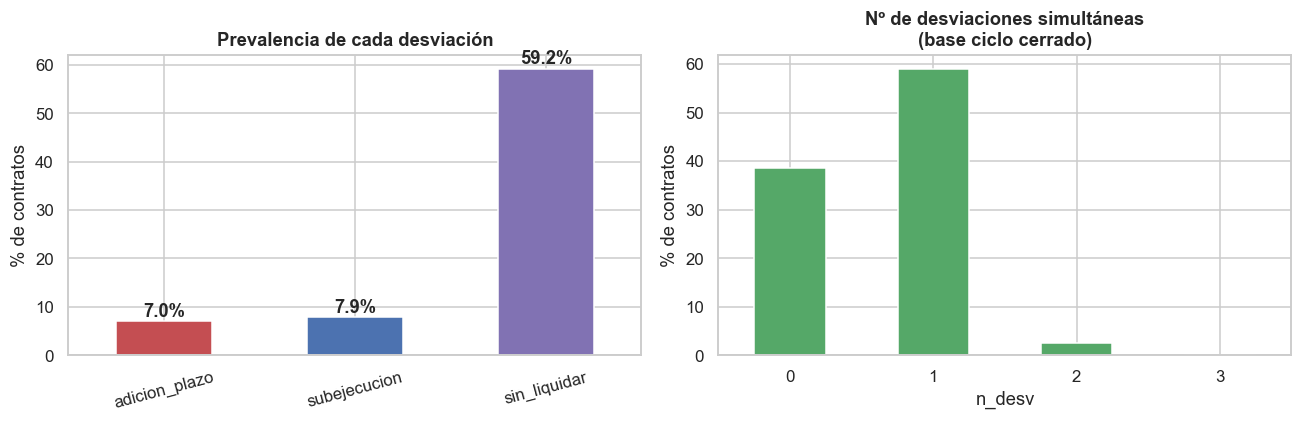

n_desv
0   38.600
1   59.000
2    2.400
3    0.000


In [3]:
# Prevalencia y solapamiento sobre la base con ciclo cerrado (donde las 3 banderas están definidas)
com = base_liq.copy()
com['f_adic'] = com['adicion_plazo'].astype(int)
com['f_sub'] = com['subejecucion'].fillna(False).astype(int)   # subejec puede ser NaN (facturado=0)
com['f_liq'] = com['sin_liquidar'].astype(int)
com['n_desv'] = com[['f_adic', 'f_sub', 'f_liq']].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
tasas_glob = pd.Series({
    'adicion_plazo': base_adic['adicion_plazo'].mean(),
    'subejecucion': base_sub['subejecucion'].mean(),
    'sin_liquidar': base_liq['sin_liquidar'].mean(),
}) * 100
tasas_glob.plot(kind='bar', ax=axes[0], color=['#C44E52', '#4C72B0', '#8172B3'])
axes[0].set_title('Prevalencia de cada desviación'); axes[0].set_ylabel('% de contratos'); axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(tasas_glob): axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

com['n_desv'].value_counts(normalize=True).sort_index().mul(100).plot(kind='bar', ax=axes[1], color='#55A868')
axes[1].set_title('Nº de desviaciones simultáneas\n(base ciclo cerrado)'); axes[1].set_ylabel('% de contratos'); axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/03_panorama.png', bbox_inches='tight'); plt.show()
print(com['n_desv'].value_counts(normalize=True).sort_index().mul(100).round(1).to_string())


Las tres desviaciones tienen prevalencias muy distintas: `sin_liquidar` es masiva (~59%), mientras
`adicion_plazo` y `subejecucion` rondan el 7–8%. La mayoría de contratos cerrados acumula **al menos una**
desviación (principalmente la no-liquidación), pero la coincidencia de las tres es poco frecuente: conviene
tratarlas como señales **complementarias**, no como un único fenómeno.


### 3.2 Desviación 1 — Adiciones de plazo

**Hipótesis:**
- **H1 (valor):** los contratos de **mayor valor** tienen más adiciones de plazo. *(H0: la distribución del valor
  es igual entre contratos con y sin adición.)*
- **H2 (modalidad):** la tasa de adición **depende de la modalidad** de contratación. *(H0: independientes.)*
- **H3 (destino):** la tasa de adición **depende del destino del gasto**.
- **H4 (proveedor PyME):** la tasa de adición **depende de si el proveedor es PyME**.


H1  valor vs adición (Mann-Whitney):
    mediana valor CON adición = 72,133,000 COP  |  SIN adición = 28,850,000 COP
    p = 0.00e+00  ->  SIGNIFICATIVO


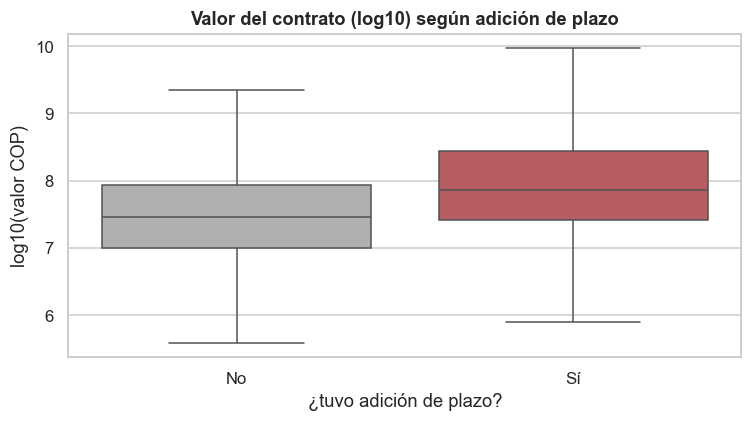

In [4]:
# H1: valor vs adición
r = test_valor(base_adic, 'adicion_plazo')
print('H1  valor vs adición (Mann-Whitney):')
print(f'    mediana valor CON adición = {r["med_desv"]:,.0f} COP  |  SIN adición = {r["med_no"]:,.0f} COP')
print(f'    p = {r["p"]:.2e}  ->  {"SIGNIFICATIVO" if r["sig"] else "no significativo"}')

fig, ax = plt.subplots(figsize=(7, 4))
sub = base_adic[base_adic['valor_log'].notna()]
sns.boxplot(data=sub, x='adicion_plazo', y='valor_log', hue='adicion_plazo', legend=False,
            ax=ax, showfliers=False, palette={False: '#B0B0B0', True: '#C44E52'})
ax.set_title('Valor del contrato (log10) según adición de plazo')
ax.set_xlabel('¿tuvo adición de plazo?'); ax.set_ylabel('log10(valor COP)')
ax.set_xticks([0, 1]); ax.set_xticklabels(['No', 'Sí'])
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/03_adicion_valor.png', bbox_inches='tight'); plt.show()


In [5]:
# H2-H4: categóricas vs adición
for h, cat in [('H2', 'modalidad_de_contratacion'), ('H3', 'destino_gasto'), ('H4', 'es_pyme')]:
    r = test_categorica(base_adic, 'adicion_plazo', cat)
    print(f'{h}  adición vs {cat}:  p={r["p"]:.2e}  V={r["V"]:.3f} ({r["efecto"]})  '
          f'-> {"SIGNIFICATIVO" if r["sig"] else "NO significativo"}')


H2  adición vs modalidad_de_contratacion:  p=0.00e+00  V=0.117 (pequeño)  -> SIGNIFICATIVO
H3  adición vs destino_gasto:  p=2.89e-105  V=0.063 (pequeño)  -> SIGNIFICATIVO


H4  adición vs es_pyme:  p=4.80e-01  V=0.002 (nulo)  -> NO significativo


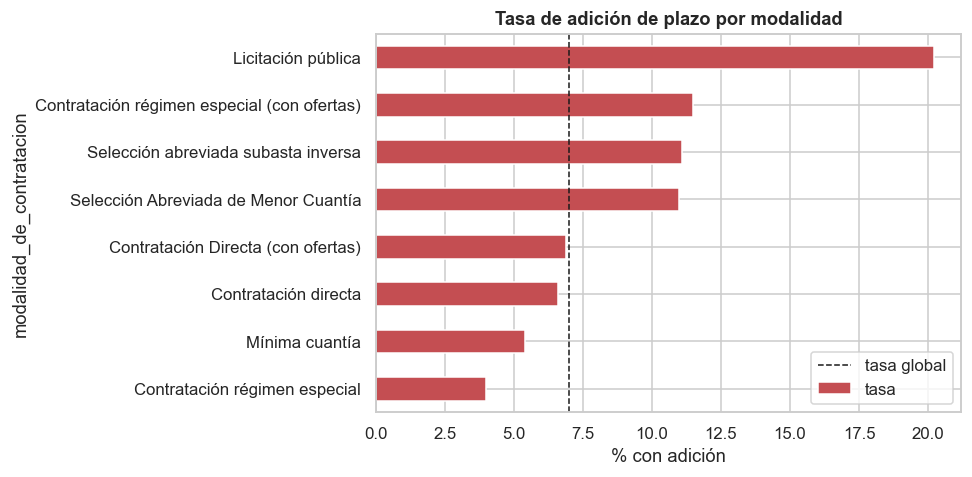

,tasa,n
modalidad_de_contratacion,,
Licitación pública,20.200,1615
Contratación régimen especial (con ofertas),11.500,3824
Selección abreviada subasta inversa,11.100,20449
Selección Abreviada de Menor Cuantía,11.000,5992
Contratación Directa (con ofertas),6.900,3421
Contratación directa,6.600,2700
Mínima cuantía,5.400,74032
Contratación régimen especial,4.000,9425


In [6]:
# Tasa de adición por modalidad (efecto más relevante)
r = test_categorica(base_adic, 'adicion_plazo', 'modalidad_de_contratacion')
fig, ax = plt.subplots(figsize=(9, 4.5))
r['tasas']['tasa'].sort_values().plot(kind='barh', ax=ax, color='#C44E52')
ax.axvline(base_adic['adicion_plazo'].mean()*100, color='k', ls='--', lw=1, label='tasa global')
ax.set_title('Tasa de adición de plazo por modalidad'); ax.set_xlabel('% con adición'); ax.legend()
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/03_adicion_modalidad.png', bbox_inches='tight'); plt.show()
r['tasas']


**Resultados — adiciones de plazo:**

- **H1 (valor): se confirma.** Los contratos con adición tienen un valor mediano varias veces mayor que los que
  no la tienen (Mann-Whitney, p ≪ 0.001). El valor es una señal temprana de riesgo de adición.
- **H2 (modalidad): se confirma** (χ² significativo, V ≈ 0.12 — el mayor efecto para esta desviación).
  **Licitación pública** presenta la tasa de adición más alta (~26%), muy por encima de **Mínima cuantía** (~7%),
  la modalidad más común. Las modalidades competitivas/de mayor cuantía concentran las adiciones.
- **H3 (destino): se confirma**, con efecto pequeño: **Inversión** adiciona más que **Funcionamiento**.
- **H4 (PyME): NO se confirma.** No hay asociación significativa entre ser PyME y las adiciones de plazo
  (χ², p > 0.05; V ≈ 0). *Resultado no significativo:* el tamaño del proveedor no discrimina esta desviación.


### 3.3 Desviación 2 — Subejecución del presupuesto

**Hipótesis:**
- **H5 (tipo de contrato):** la subejecución **depende del tipo** (Suministros vs Compraventa).
- **H6 (destino):** la subejecución **depende del destino del gasto**.
- **H7 (valor):** los contratos de **mayor valor** subejecutan más.
- **H8 (sector):** la subejecución **depende del sector**.

*(Recordatorio de `01`–`02`: por el subreporte de `valor_pagado`, la subejecución se mide con `valor_facturado`
y solo sobre contratos cerrados con ejecución reportada.)*


In [7]:
for h, cat in [('H5', 'tipo_de_contrato'), ('H6', 'destino_gasto'), ('H8', 'sector')]:
    r = test_categorica(base_sub, 'subejecucion', cat)
    print(f'{h}  subejecución vs {cat}:  p={r["p"]:.2e}  V={r["V"]:.3f} ({r["efecto"]})  '
          f'-> {"SIGNIFICATIVO" if r["sig"] else "NO significativo"}')
r7 = test_valor(base_sub, 'subejecucion')
print(f'H7  valor vs subejecución (Mann-Whitney): mediana desv={r7["med_desv"]:,.0f}  no={r7["med_no"]:,.0f}  '
      f'p={r7["p"]:.2e} -> {"SIGNIFICATIVO" if r7["sig"] else "no significativo"}')


H5  subejecución vs tipo_de_contrato:  p=0.00e+00  V=0.196 (moderado)  -> SIGNIFICATIVO
H6  subejecución vs destino_gasto:  p=1.47e-68  V=0.091 (pequeño)  -> SIGNIFICATIVO
H8  subejecución vs sector:  p=1.69e-115  V=0.127 (pequeño)  -> SIGNIFICATIVO
H7  valor vs subejecución (Mann-Whitney): mediana desv=54,803,795  no=30,000,000  p=7.40e-78 -> SIGNIFICATIVO


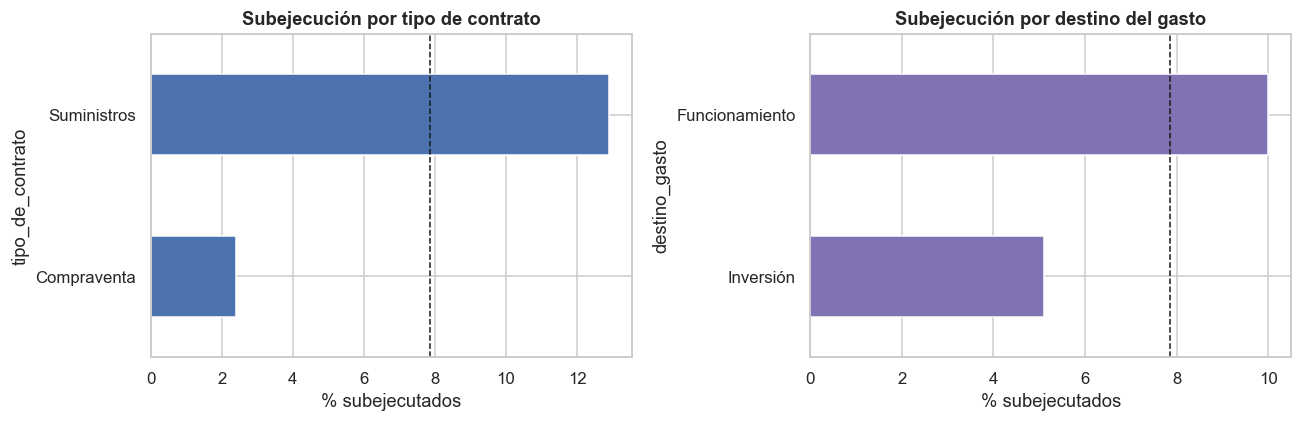

In [8]:
# Tasa de subejecución por tipo de contrato y por destino
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, cat, titulo, color in [(axes[0], 'tipo_de_contrato', 'Tipo de contrato', '#4C72B0'),
                               (axes[1], 'destino_gasto', 'Destino del gasto', '#8172B3')]:
    t = test_categorica(base_sub, 'subejecucion', cat)['tasas']['tasa']
    t.sort_values().plot(kind='barh', ax=ax, color=color)
    ax.axvline(base_sub['subejecucion'].mean()*100, color='k', ls='--', lw=1)
    ax.set_title(f'Subejecución por {titulo.lower()}'); ax.set_xlabel('% subejecutados')
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/03_subejec_tipo_destino.png', bbox_inches='tight'); plt.show()


**Resultados — subejecución:**

- **H5 (tipo): se confirma con el mayor efecto** (V ≈ 0.20). Los **Suministros** subejecutan mucho más
  (~13%) que la **Compraventa** (~2%): coherente con que el suministro es entrega continua que puede no
  agotar el monto comprometido.
- **H6 (destino): se confirma.** **Funcionamiento** subejecuta más (~10%) que **Inversión** (~5%).
- **H7 (valor): se confirma.** Los contratos subejecutados tienen valor mediano mayor (p ≪ 0.001).
- **H8 (sector): se confirma**, con efecto moderado (V ≈ 0.13): hay sectores sistemáticamente más propensos.


### 3.4 Desviación 3 — Cierre sin liquidar

**Hipótesis:**
- **H9 (sector):** la no-liquidación **depende del sector**.
- **H10 (orden):** las entidades **territoriales** liquidan menos que las **nacionales**.
- **H11 (modalidad):** la no-liquidación **depende de la modalidad**.
- **H12 (valor):** los contratos de **mayor valor** se liquidan **menos**.


In [9]:
for h, cat in [('H9', 'sector'), ('H10', 'orden'), ('H11', 'modalidad_de_contratacion')]:
    r = test_categorica(base_liq, 'sin_liquidar', cat)
    print(f'{h}  sin_liquidar vs {cat}:  p={r["p"]:.2e}  V={r["V"]:.3f} ({r["efecto"]})  '
          f'-> {"SIGNIFICATIVO" if r["sig"] else "NO significativo"}')
r12 = test_valor(base_liq, 'sin_liquidar')
print(f'H12 valor vs sin_liquidar (Mann-Whitney): mediana SIN liquidar={r12["med_desv"]:,.0f}  '
      f'liquidados={r12["med_no"]:,.0f}  p={r12["p"]:.2e} -> {"SIGNIFICATIVO" if r12["sig"] else "no sig"}')


H9  sin_liquidar vs sector:  p=0.00e+00  V=0.316 (fuerte)  -> SIGNIFICATIVO
H10  sin_liquidar vs orden:  p=3.73e-277  V=0.136 (pequeño)  -> SIGNIFICATIVO
H11  sin_liquidar vs modalidad_de_contratacion:  p=0.00e+00  V=0.194 (moderado)  -> SIGNIFICATIVO


H12 valor vs sin_liquidar (Mann-Whitney): mediana SIN liquidar=27,988,650  liquidados=42,150,000  p=5.42e-251 -> SIGNIFICATIVO


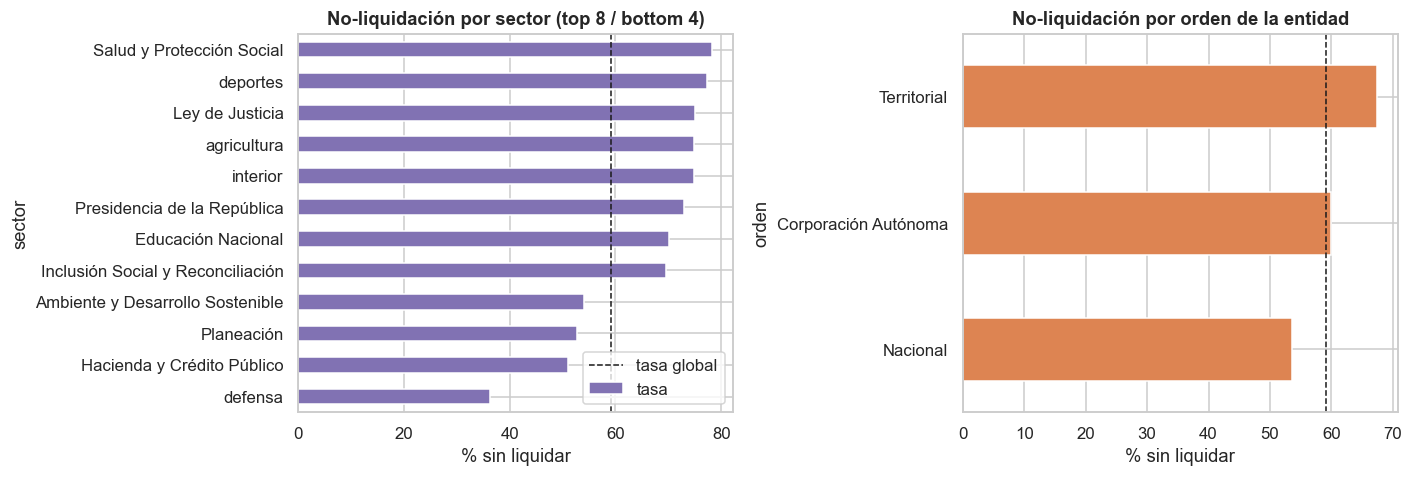

In [10]:
# Tasa de no-liquidación por sector (efecto más fuerte) y por orden
r = test_categorica(base_liq, 'sin_liquidar', 'sector')
top = pd.concat([r['tasas'].head(8), r['tasas'].tail(4)])
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
top['tasa'].sort_values().plot(kind='barh', ax=axes[0], color='#8172B3')
axes[0].axvline(base_liq['sin_liquidar'].mean()*100, color='k', ls='--', lw=1, label='tasa global')
axes[0].set_title('No-liquidación por sector (top 8 / bottom 4)'); axes[0].set_xlabel('% sin liquidar'); axes[0].legend()

test_categorica(base_liq, 'sin_liquidar', 'orden')['tasas']['tasa'].sort_values().plot(kind='barh', ax=axes[1], color='#DD8452')
axes[1].axvline(base_liq['sin_liquidar'].mean()*100, color='k', ls='--', lw=1)
axes[1].set_title('No-liquidación por orden de la entidad'); axes[1].set_xlabel('% sin liquidar')
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/03_sinliq_sector_orden.png', bbox_inches='tight'); plt.show()


**Resultados — cierre sin liquidar:**

- **H9 (sector): se confirma y es el efecto más fuerte de todo el análisis** (V ≈ 0.32). Sectores como
  **Salud y Protección Social** superan el ~78% sin liquidar, frente a **defensa** (~36%). El sector es el
  criterio de focalización más discriminante para esta desviación.
- **H10 (orden): se confirma.** Las entidades **Territoriales** liquidan menos (~67% sin liquidar) que las
  **Nacionales** (~54%).
- **H11 (modalidad): se confirma** (V ≈ 0.19).
- **H12 (valor): se confirma, pero en sentido inverso al de las otras desviaciones:** los contratos que se
  cierran **sin liquidar** tienen valor mediano **menor** que los liquidados (p ≪ 0.001). La no-liquidación se
  concentra en contratos **pequeños** —posiblemente por menor exigencia de trámite—, al contrario que las
  adiciones y la subejecución, que crecen con el valor.


### 3.5 Vista multivariada: segmentos de alto riesgo

Combinamos atributos para localizar segmentos accionables. Mapas de calor de la tasa de desviación por
**modalidad × destino** (adición) y **sector × orden** (no-liquidación).


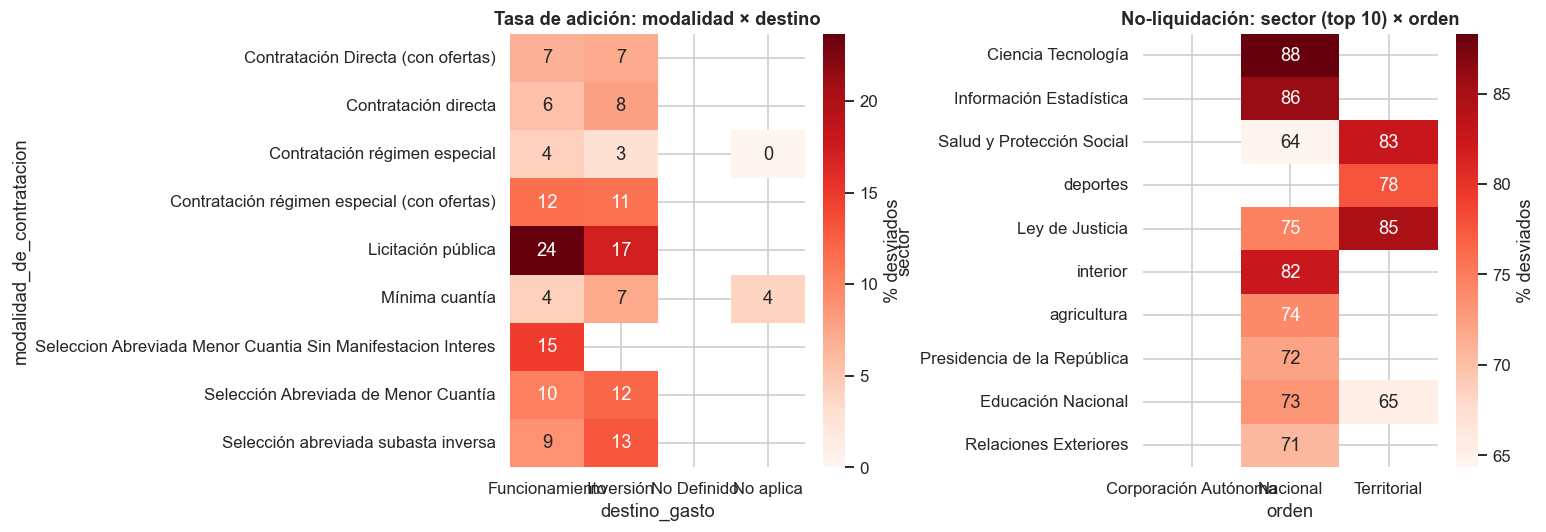

In [11]:
def heatmap_tasa(df, flag, fila, col, ax, titulo, min_n=100, top_filas=None):
    sub = df[df[flag].notna()].copy(); sub[flag] = sub[flag].astype(bool)
    piv = sub.pivot_table(index=fila, columns=col, values=flag, aggfunc='mean') * 100
    cnt = sub.pivot_table(index=fila, columns=col, values=flag, aggfunc='size')
    piv = piv.mask(cnt < min_n)  # ocultar celdas con poca muestra
    if top_filas:
        orden_f = sub.groupby(fila)[flag].mean().sort_values(ascending=False).head(top_filas).index
        piv = piv.loc[[f for f in orden_f if f in piv.index]]
    sns.heatmap(piv, annot=True, fmt='.0f', cmap='Reds', ax=ax, cbar_kws={'label': '% desviados'})
    ax.set_title(titulo)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
heatmap_tasa(base_adic, 'adicion_plazo', 'modalidad_de_contratacion', 'destino_gasto', axes[0],
             'Tasa de adición: modalidad × destino')
heatmap_tasa(base_liq, 'sin_liquidar', 'sector', 'orden', axes[1],
             'No-liquidación: sector (top 10) × orden', top_filas=10)
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/03_heatmaps.png', bbox_inches='tight'); plt.show()


Los mapas confirman **interacción** entre atributos: dentro de cada modalidad, Inversión adiciona más que
Funcionamiento; y la no-liquidación es más severa en la combinación de ciertos sectores con entidades
territoriales. Estos cruces son la base de los criterios de focalización del informe ejecutivo.


### 3.6 Síntesis de hipótesis contrastadas

In [12]:
filas = []
def add(h, desc, prueba, r, tipo='cat'):
    if tipo == 'cat':
        filas.append([h, desc, prueba, f'p={r["p"]:.1e}', f'V={r["V"]:.3f} ({r["efecto"]})',
                      'Sí' if r['sig'] else 'No'])
    else:
        filas.append([h, desc, prueba, f'p={r["p"]:.1e}',
                      f'med {r["med_desv"]:,.0f} vs {r["med_no"]:,.0f}', 'Sí' if r['sig'] else 'No'])

add('H1', 'Adición ~ valor', 'Mann-Whitney', test_valor(base_adic, 'adicion_plazo'), 'num')
add('H2', 'Adición ~ modalidad', 'χ²', test_categorica(base_adic, 'adicion_plazo', 'modalidad_de_contratacion'))
add('H3', 'Adición ~ destino', 'χ²', test_categorica(base_adic, 'adicion_plazo', 'destino_gasto'))
add('H4', 'Adición ~ es_pyme', 'χ²', test_categorica(base_adic, 'adicion_plazo', 'es_pyme'))
add('H5', 'Subejecución ~ tipo', 'χ²', test_categorica(base_sub, 'subejecucion', 'tipo_de_contrato'))
add('H6', 'Subejecución ~ destino', 'χ²', test_categorica(base_sub, 'subejecucion', 'destino_gasto'))
add('H7', 'Subejecución ~ valor', 'Mann-Whitney', test_valor(base_sub, 'subejecucion'), 'num')
add('H8', 'Subejecución ~ sector', 'χ²', test_categorica(base_sub, 'subejecucion', 'sector'))
add('H9', 'Sin liquidar ~ sector', 'χ²', test_categorica(base_liq, 'sin_liquidar', 'sector'))
add('H10', 'Sin liquidar ~ orden', 'χ²', test_categorica(base_liq, 'sin_liquidar', 'orden'))
add('H11', 'Sin liquidar ~ modalidad', 'χ²', test_categorica(base_liq, 'sin_liquidar', 'modalidad_de_contratacion'))
add('H12', 'Sin liquidar ~ valor', 'Mann-Whitney', test_valor(base_liq, 'sin_liquidar'), 'num')

resumen = pd.DataFrame(filas, columns=['H', 'Hipótesis', 'Prueba', 'p-valor', 'Tamaño de efecto', 'Signif.'])
resumen


,H,Hipótesis,Prueba,p-valor,Tamaño de efecto,Signif.
0,H1,Adición ~ valor,Mann-Whitney,p=0.0e+00,"med 72,133,000 vs 28,850,000",Sí
1,H2,Adición ~ modalidad,χ²,p=0.0e+00,V=0.117 (pequeño),Sí
2,H3,Adición ~ destino,χ²,p=2.9e-105,V=0.063 (pequeño),Sí
3,H4,Adición ~ es_pyme,χ²,p=4.8e-01,V=0.002 (nulo),No
4,H5,Subejecución ~ tipo,χ²,p=0.0e+00,V=0.196 (moderado),Sí
5,H6,Subejecución ~ destino,χ²,p=1.5e-68,V=0.091 (pequeño),Sí
6,H7,Subejecución ~ valor,Mann-Whitney,p=7.4e-78,"med 54,803,795 vs 30,000,000",Sí
7,H8,Subejecución ~ sector,χ²,p=1.7e-115,V=0.127 (pequeño),Sí
8,H9,Sin liquidar ~ sector,χ²,p=0.0e+00,V=0.316 (fuerte),Sí
9,H10,Sin liquidar ~ orden,χ²,p=3.7e-277,V=0.136 (pequeño),Sí


## 4. Insights principales

1. **El valor del contrato es una señal temprana** de riesgo, pero con dirección distinta según la desviación:
   a **mayor valor**, más **adiciones** y más **subejecución**; a **menor valor**, más **no-liquidación**.
2. **La modalidad importa para las adiciones**: Licitación pública y selección abreviada adicionan mucho más que
   Mínima cuantía.
3. **El tipo de contrato es el mejor discriminador de la subejecución**: los **Suministros** subejecutan ~5×
   más que la Compraventa; **Funcionamiento** más que Inversión.
4. **El sector es el criterio más potente para la no-liquidación** (efecto fuerte), agravado en entidades
   **territoriales**. La no-liquidación es además un problema **masivo** (~59%).
5. **Resultado no significativo relevante:** el **tamaño del proveedor (PyME)** no discrimina las desviaciones
   (no significativo para adición ni liquidación) — no es un buen criterio de focalización.

> **Advertencia metodológica:** con esta muestra tan grande, la significancia estadística no basta; las
> conclusiones anteriores se sostienen en el **tamaño de efecto** (V de Cramér, diferencias de mediana), no solo
> en el p-valor.

**Siguiente paso:** informe ejecutivo (Entregable 4) con los criterios de focalización priorizados y las
limitaciones del análisis.
